In [ ]:
# 1. Overview
# This project focuses on predicting property prices in various districts of California using
# several district-level features. By building a predictive model, we aim to identify key variables
# that influence housing prices and improve the accuracy of house value predictions. The
# project will specifically utilize simple linear regression and multiple linear regression to
# address this regression task, ensuring proper data handling and evaluation of the models.

# 2. Problem Statement: 
# The objective is to predict the median house value in California districts based on features
# such as income, the number of rooms, geographical location, and proximity to the ocean.
# Given the dataset, we will develop regression models, evaluate their performance, and
# determine which model provides the best balance between predictive accuracy and
# interpretability.

# 3. Dataset Information
# Dataset: Housing Prices
# The information related to variables given can be found in the Data Information.pdf.

# 4. Deliverables
# ● Exploratory Data Analysis (EDA) with visualizations and summary statistics.
# ● Data Preprocessing, including handling missing values and encoding categorical variables.
# ● Model development using:
# o Simple Linear Regression
# o Multiple Linear Regression
# ● Evaluation of the models using relevant metrics (Confusion Matrix, Precision, Recall,
# F1-Score, etc.) where applicable.
# ● A final, well-documented notebook detailing all steps, insights, and the final model
# selection.

# 5. Success Criteria
# ● The model should have a high degree of accuracy and balance with interpretability.
# ● The evaluation metrics such as MSE, RMSE and R Square will be used to measure
# the model’s performance.
# ● Ensure proper documentation of all steps, and present visualizations that help explain the data and model outcomes.

# 6. Guidelines
# ● Make sure to split your data into training and testing sets to avoid overfitting.
# ● Tune the hyperparameters of your models to improve performance.
# ● Report all the steps taken in the data preprocessing, modeling, and evaluation
# phases.
# ● Provide a final model that balances accuracy with interpretability.

# 7. Tools Required
# ● Python (with libraries such as pandas, scikit-learn, matplotlib, seaborn, etc.)
# ● Jupyter Notebook or any IDE suitable for running Python code

In [98]:
# Import all libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('Housing Prices.csv')
df.head() # Display the 1st few rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [99]:
# Display basic information
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [100]:
# Summary Statistics of the dataset
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


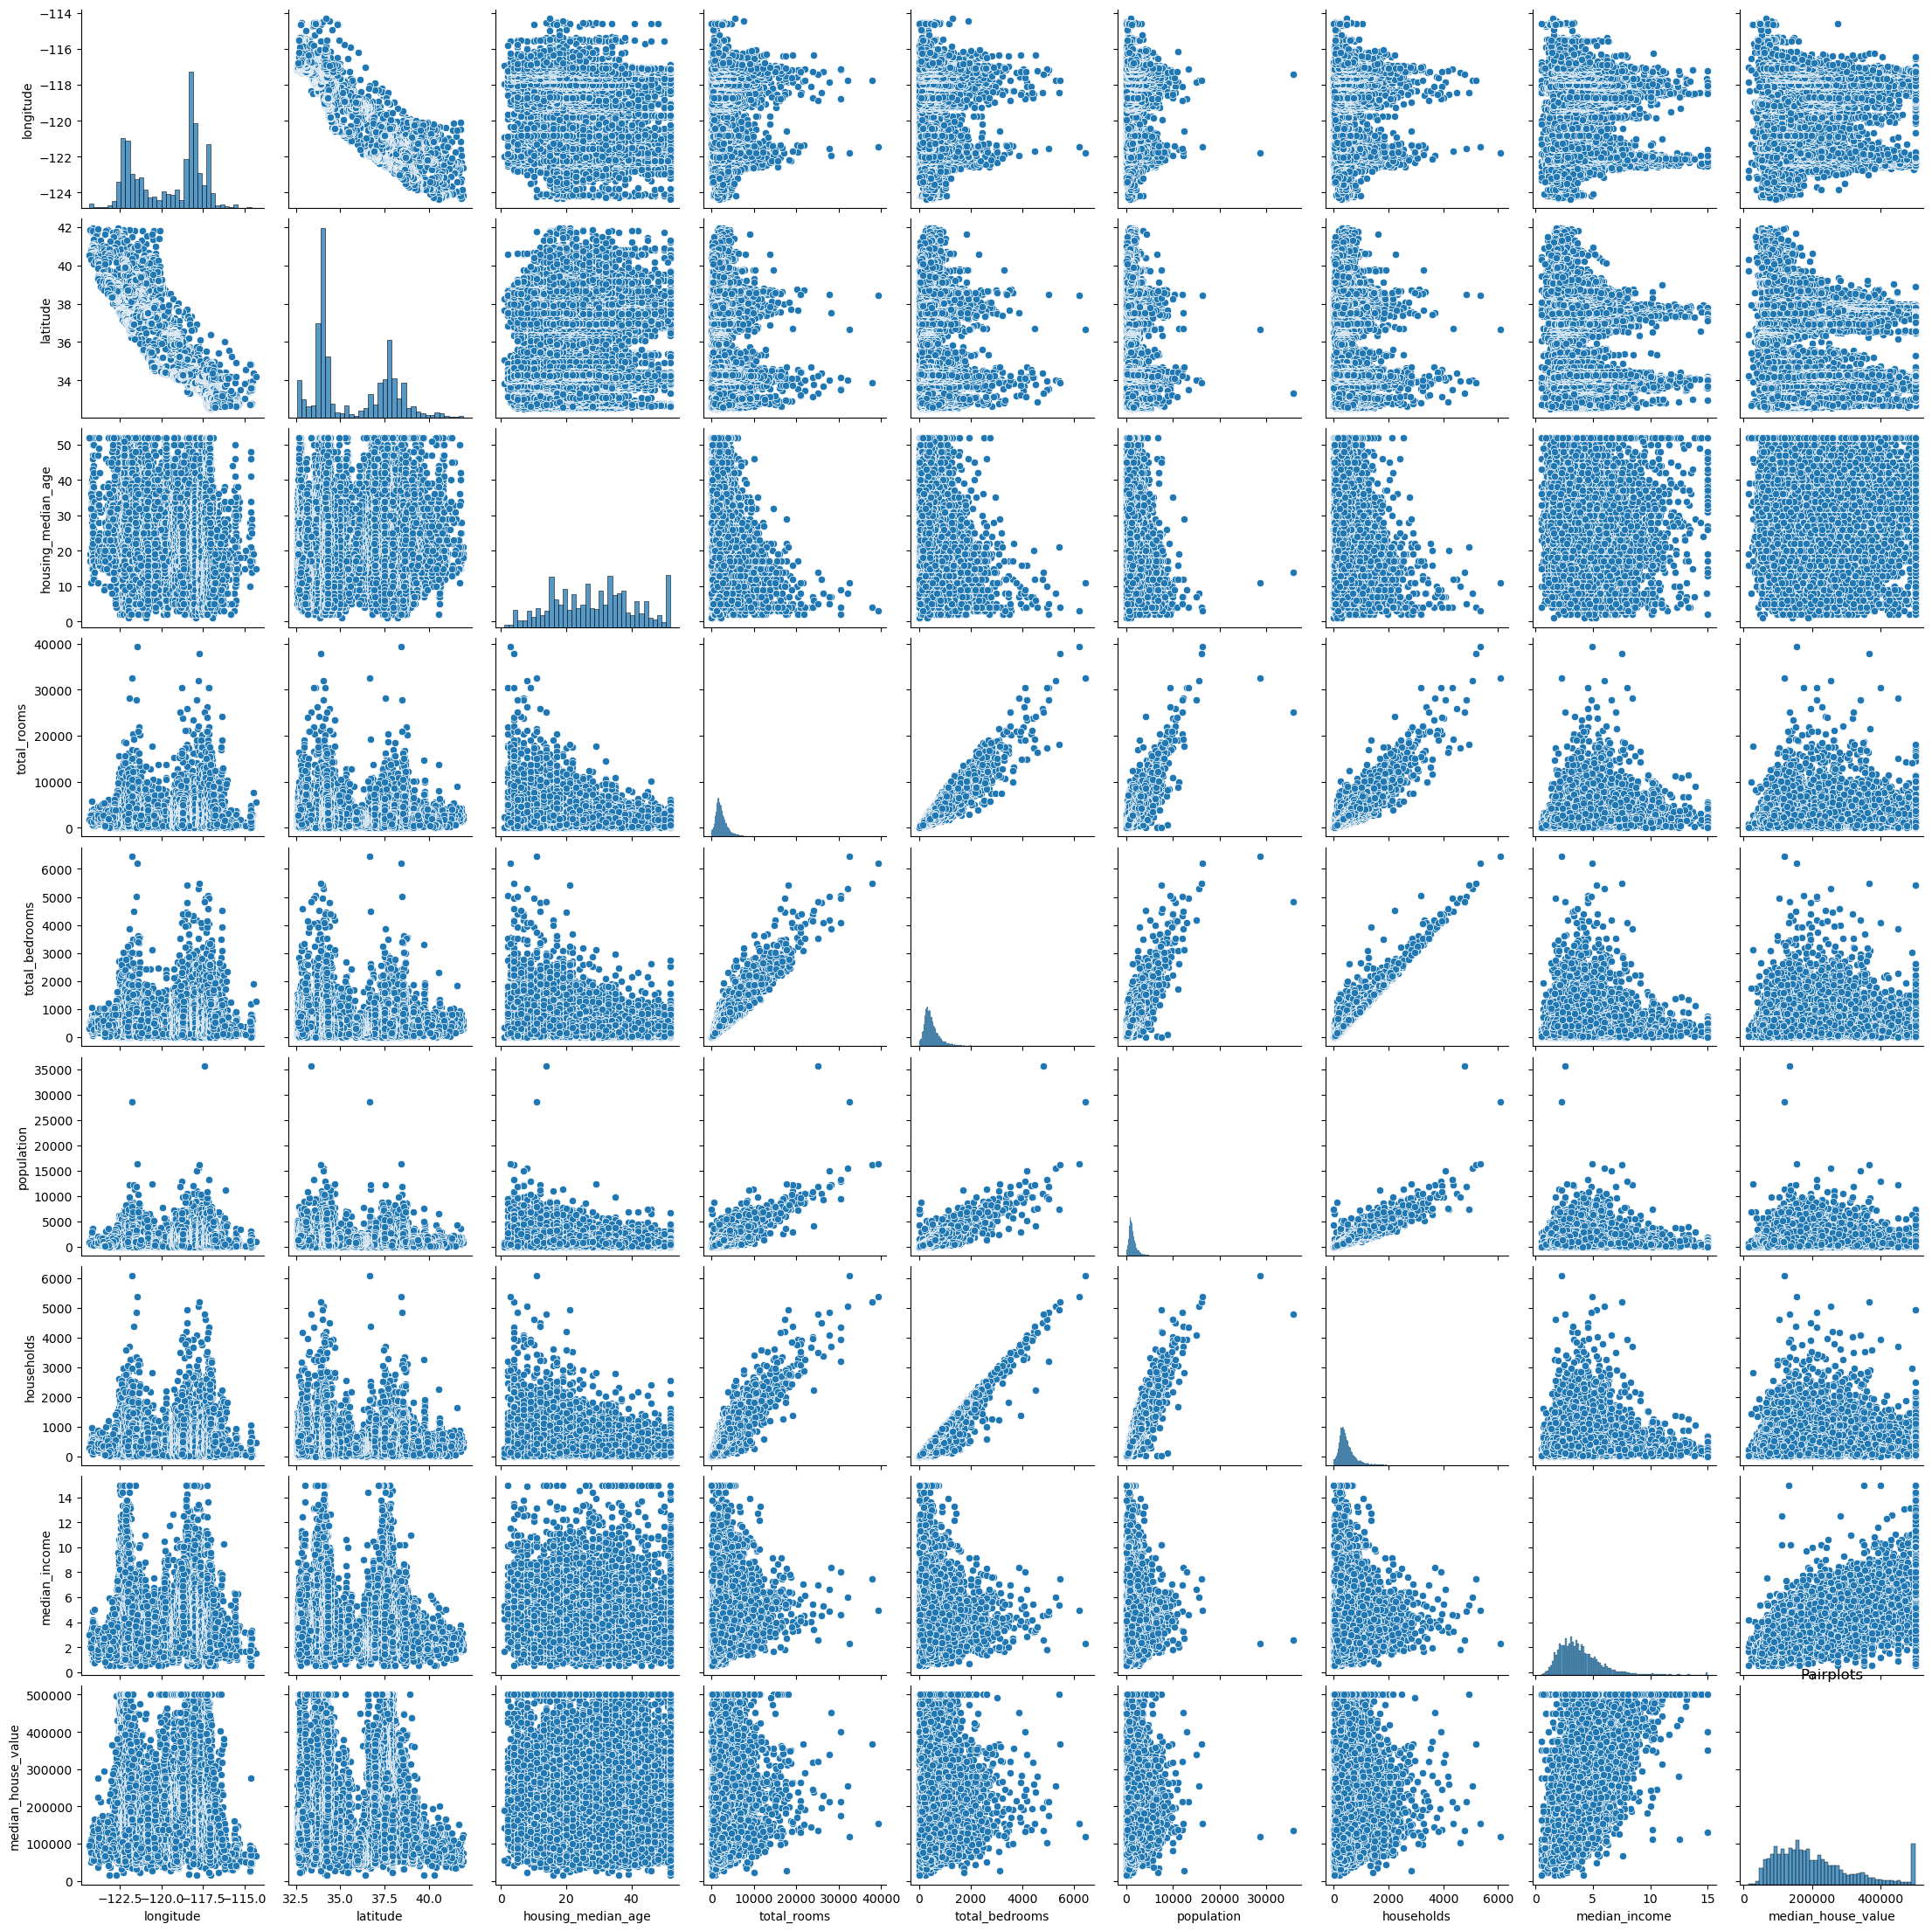

In [101]:
# Pairplot is to visualise relationship betweeen any two variables
sns.pairplot(df)
plt.show()

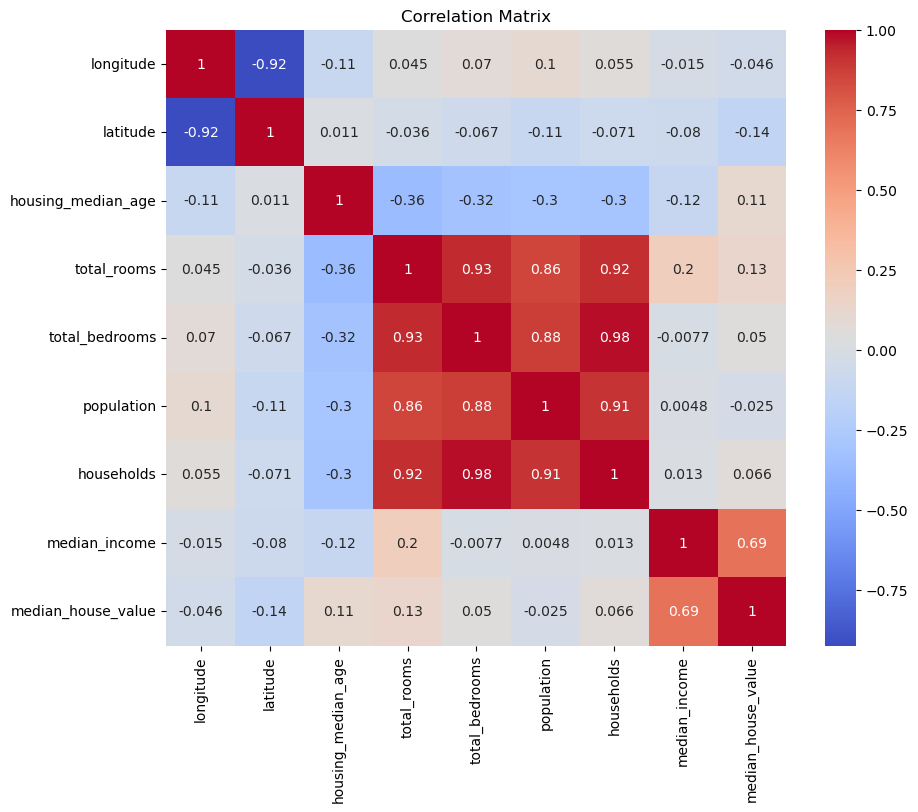

In [102]:
# Correlation Matrix
correlation_matrix= df.corr(numeric_only=True)
plt.figure(figsize=(10,8)) # 10 rows and 8 columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# annot=True
# What it does: Short for "annotate." It writes the actual numerical correlation value inside each square of the heatmap.
# Why use it: Without this, you only see the colors. Adding the numbers allows for precision, 
#             letting you see exactly how strong a relationship is (e.g., 0.82 vs 0.85)
plt.title('Correlation Matrix')
plt.show()

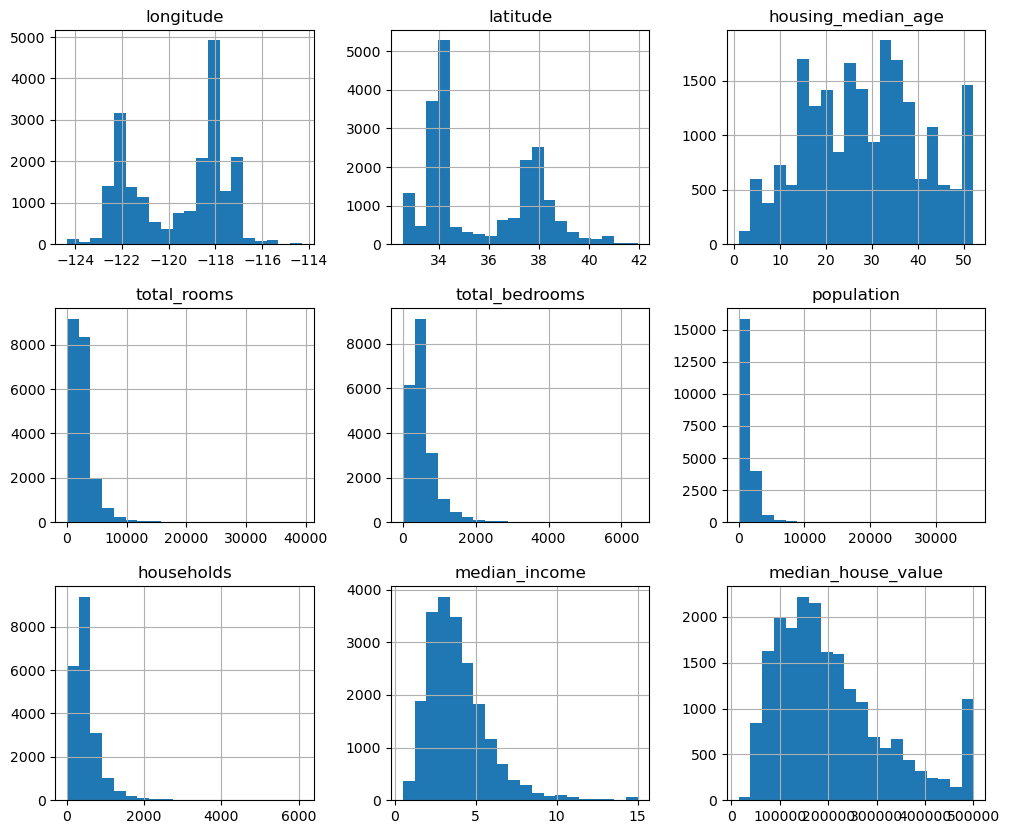

In [103]:
# Histograms of Individual features
df.hist(figsize=(12,10),bins=20)
plt.show()
# 1. df.hist(): This is the core method. When called on a DataFrame (df), it automatically identifies all numerical columns and 
# generates a separate histogram for each one. 
# It acts as a "wrapper" that calls the Matplotlib hist() function for every series in your data. 

# 2. figsize=(12, 10)
# This parameter controls the physical size of the entire plotting area (the "figure"). 
# 12: The width in inches.
# 10: The height in inches.
# Why use it? :: By default, subplots can look cramped. 
#                Increasing these numbers ensures that the individual histograms are large enough to read clearly, especially when your DataFrame 
#                has many columns. 

# 3. bins=20: This defines the number of intervals (or "buckets") used to group your data points. 
# The Logic: If your data ranges from 0 to 100, bins=20 will create 20 equal-width bars, each covering a range of 5 units (e.g., 0-5, 5-10, etc.).
# The Impact: (i) Higher bins (like 20 or 50) provide more granularity and detail but can make the plot look "noisy" if there isn't enough data.
#             (ii)Lower bins (the default is 10) provide a smoother, generalized view but might hide important local patterns. 

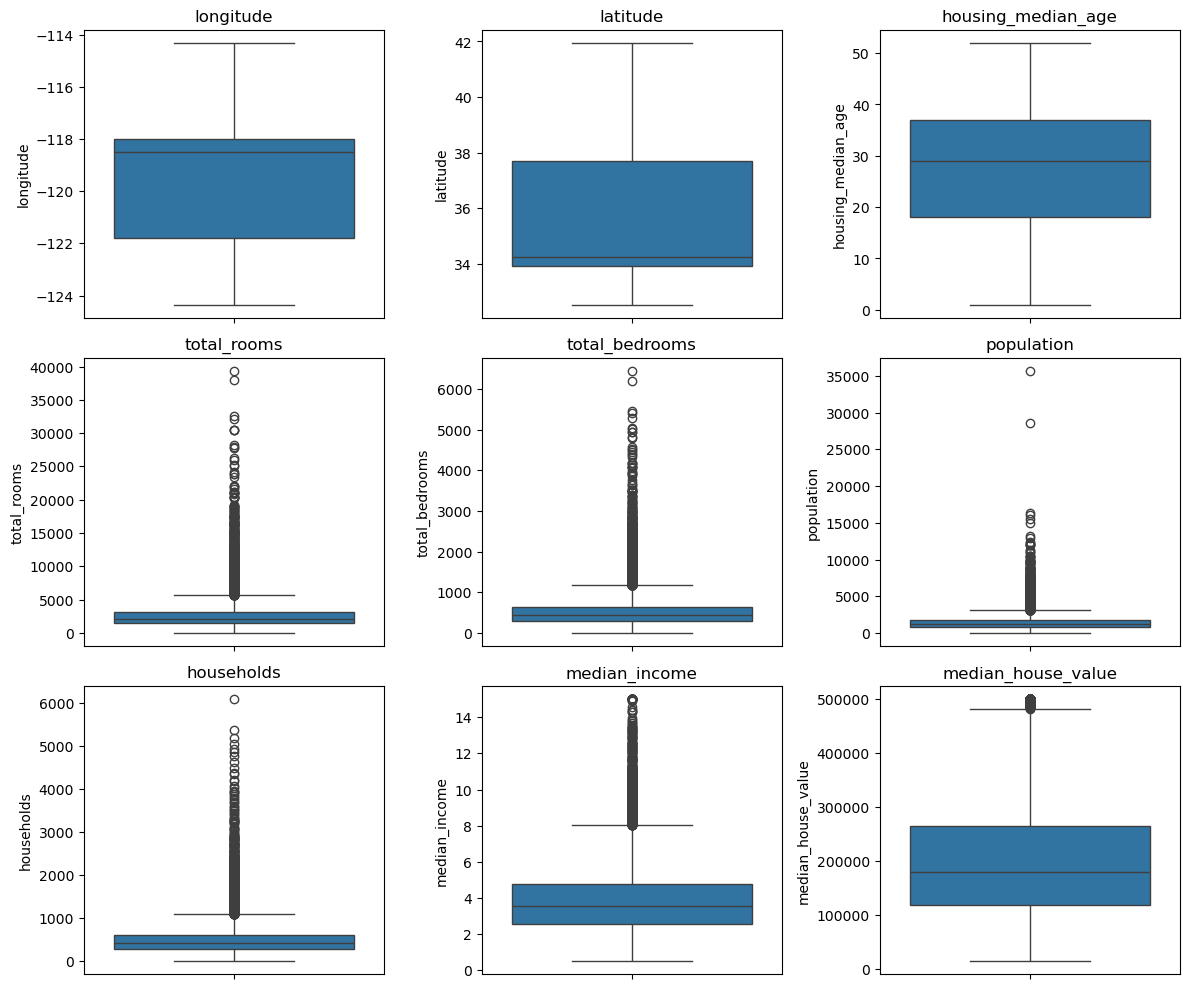

In [104]:
# Box Plots to check for outliers
plt.figure(figsize=(12,10))
for i, column in enumerate(df.columns):
    if i<9: # to iterate the values of i from 0 to 8 so i+1 goes from 1 to 9
        plt.subplot(3,3,i+1) # Create a 3x3 grid for 9 different plots 
        sns.boxplot(df[column]) 
        plt.title(column)
plt.tight_layout()
plt.show()

In [105]:
#plt.figure(figsize=(12,10))
# for i, column in enumerate(df.columns):
  #  plt.subplot(4,3,i+1) # Create a 4x3 grid for 9 different plots (4 rows, 3 columns)
  #  sns.boxplot(df[column])
  #  plt.title(column)
# plt.tight_layout()
# plt.show()

In [106]:
# Simple Linear Regression

# Define the Target variable and the Predictor Variabl
X=df[['median_income']]       # Predictor Variable 
# X=df['median_income'] : returns a series(1D) 
# X=df[['median_income']] : returns an array(2D)
y=df['median_house_value']    # Target variable

# Split the dataset into training data and testing data (Training Data - 80% ,Testing Data - 20%)
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)


# Create and train the model
simple_model=LinearRegression()
simple_model.fit(X_train, y_train)

# Prediction
y_pred=simple_model.predict(X_test)

# Evaluate the model
print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R^2 Score: {r2_score(y_test, y_pred)}')

Mean Squared Error: 7091157771.76555
R^2 Score: 0.45885918903846656


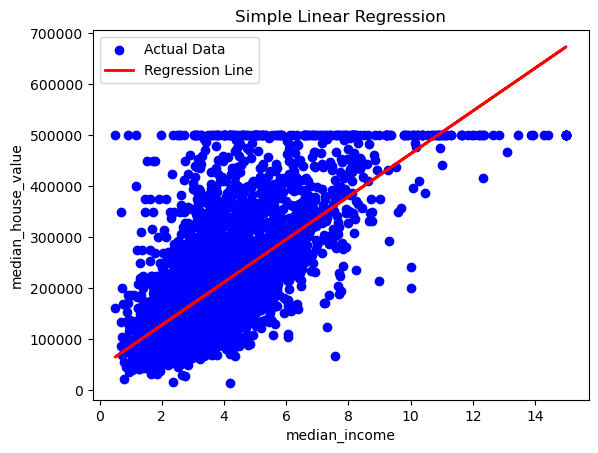

In [107]:
# Plot the Regression Line
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [108]:
# Results:
# R^2= 0.4588 or 45% of the variation is explained 

In [111]:
# Assuming that the model has already been trained and relevant libraries have been imported
# Input Median Income values from the user
median_income_value=float(input('Enter the Median Income Value: '))
# Convert the input into a 2D array for the model
median_income_value_array=np.array([[median_income_value]])
# Predict the house price using the trained model
predicted_price=simple_model.predict(median_income_value_array)
# Print the prediction 
print(f'The Predicted House Price for Median Income of {median_income_value} is : $ {predicted_price}:.2f')

Enter the Median Income Value:  8.5648


The Predicted House Price for Median Income of 8.5648 is : $ [403614.76245721]:.2f
